In [1]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
import gymnasium as gym

In [3]:
from gymnasium.envs.registration import register

register(
    id = "FrozenLakeNotSlippery",
    entry_point="gymnasium.envs.toy_text:FrozenLakeEnv",
    kwargs = {'map_name': '4x4', 'is_slippery' : False},
    max_episode_steps = 100,
    reward_threshold = 0.78
)

In [4]:
env = gym.make('FrozenLakeNotSlippery')
env_hum = gym.make('FrozenLakeNotSlippery', render_mode = 'human')

In [5]:
env_hum.reset()

/home/ozgurk33/anaconda3/envs/ai_rl_course/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


(0, {'prob': 1})

In [6]:
for step in range(50):
    env_hum.render()
    action = env_hum.action_space.sample()
    observation, reward, terminated, truncated, info = env_hum.step(action)
    time.sleep(0.1)

    if truncated or terminated:
        env_hum.reset()


In [7]:
action_size = env.action_space.n
state_size = env.observation_space.n
q_table = np.zeros([state_size, action_size])

In [8]:
q_table.shape

(16, 4)

In [9]:
q_table

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [10]:
EPOCHS = 20000

In [11]:
ALPHA = 0.8
GAMMA = 0.95

In [12]:
epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.001

In [13]:
def epsilon_greedy_action_selection(epsilon, q_table, discrete_state):
    random_num = np.random.random()

    if random_num > epsilon:
        state_row = q_table[discrete_state, :]

        action = np.argmax(state_row)

    else:
        action = env.action_space.sample()

    return action

In [14]:
def compute_next_q_value(old_q_value, reward, next_optimal_q_value):

    return old_q_value + ALPHA*(reward + GAMMA * next_optimal_q_value - old_q_value)

In [15]:
def reduce_epsilon(epsilon, epoch):
    return min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate * epoch)

In [16]:
state, info = env.reset()

In [22]:
from IPython.display import clear_output, display

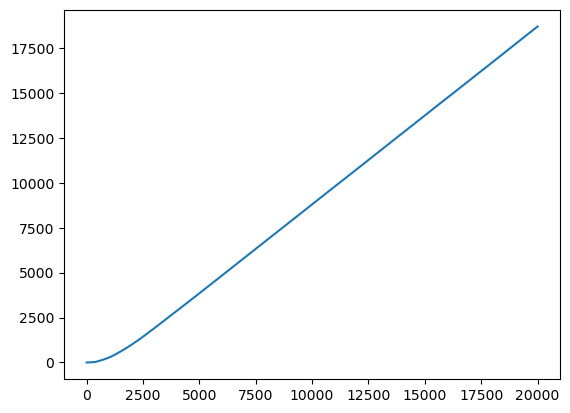

In [23]:
rewards = []
log_interval = 1000

fig = plt.figure()
ax = fig.add_subplot(111)
epoch_plot_tracker = []
total_reward_plot_tracker = []

for episode in range(EPOCHS):
    state, info = env.reset()
    truncated = terminated = False
    total_reward = 0

    while not (truncated or terminated):
        action = epsilon_greedy_action_selection(epsilon, q_table, state)

        new_state, reward, terminated, truncated, info = env.step(action)

        old_q_value = q_table[state, action]

        next_optimal_q_value = np.max(q_table[new_state,:])

        next_q = compute_next_q_value(old_q_value, reward, next_optimal_q_value)

        q_table[state, action] = next_q

        total_reward += reward

        state = new_state
    episode +=1

    epsilon = reduce_epsilon(epsilon, episode)

    rewards.append(total_reward)

    total_reward_plot_tracker.append(np.sum(rewards))
    epoch_plot_tracker.append(episode)

    if episode % log_interval == 0:
        clear_output(wait=True)
        ax.clear()
        ax.plot(epoch_plot_tracker, total_reward_plot_tracker)
        display(fig)

In [24]:
q_table

array([[0.73509189, 0.77378094, 0.77378094, 0.73509189],
       [0.73509189, 0.        , 0.81450625, 0.77378094],
       [0.77378094, 0.857375  , 0.77378094, 0.81450625],
       [0.81450625, 0.        , 0.77378094, 0.77378094],
       [0.77378094, 0.81450625, 0.        , 0.73509189],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.        , 0.81450625],
       [0.        , 0.        , 0.        , 0.        ],
       [0.81450625, 0.        , 0.857375  , 0.77378094],
       [0.81450625, 0.9025    , 0.9025    , 0.        ],
       [0.857375  , 0.95      , 0.        , 0.857375  ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.95      , 0.857375  ],
       [0.9025    , 0.95      , 1.        , 0.9025    ],
       [0.        , 0.        , 0.        , 0.        ]])

In [25]:
state, info = env_hum.reset()

time.sleep(2)
for step in range(100):
    env_hum.render()
    action = np.argmax(q_table[state, :])
    state, reward, terminated, truncated, info = env_hum.step(action)

    time.sleep(1)

    if terminated | truncated:
        break

In [26]:
env.close()
env_hum.close()